In [1]:

from pymongo import MongoClient
import pandas as pd

try: 
    client = MongoClient("localhost", 27017)
    print("Connected successfully!!!") 
except:
    print("Could not connect to MongoDB")

db = client["flask_db"]
activity = db.activity



Connected successfully!!!


/var/folders/b4/tsyrjt4j47766fqchqsyvycm0000gn/T/ipykernel_44049/2007306756.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
query = {"project": "656fadd102ae94a7686aae62", "editingLines": {"$exists": True, "$ne": None}}

cursor = activity.find(query)

df = pd.DataFrame(list(cursor))
#df = df.astype({"text": str, "state": str, "line": str, "username": str, "project": str, "file": str, "message": str})

col_names = df.columns.tolist()
dtypes = df.dtypes
df.head()

,_id,timestamp,text,revision,state,line,username,project,file,editingLines,message,changes,clipboard,cb
0,65708e17ea0333c46f1ce0d5,1701875222539,,"[[-1, % This must be in the first 5 lines to t...",Typing,1,das00015@umn.edu,656fadd102ae94a7686aae62,introduction.tex,[1],Typing,"[(1,0), % This must be in the first 5 lines to...",NaN,NaN
1,65710cb4ea0333c46f1ce11f,1701907635170,%I change the title to be more NLP-ish - Shirl...,"[[0, %I change the title to be more NLP-ish - ...",Typing,139,karin,656fadd102ae94a7686aae62,acl_latex.tex,"[103, 104, 105, 106, 107, 108, 109, 110, 111, ...",Typing,"[(139,0), \n---added]",NaN,NaN
2,65710cbfea0333c46f1ce120,1701907646740,%I change the title to be more NLP-ish - Shirl...,"[[0, %I change the title to be more NLP-ish - ...",Typing,139,karin,656fadd102ae94a7686aae62,acl_latex.tex,"[103, 104, 105, 106, 107, 108, 109, 110, 111, ...",Typing,"[(139,0), \karin{DebL }---added]",NaN,NaN
3,65710cc0ea0333c46f1ce121,1701907647197,%I change the title to be more NLP-ish - Shirl...,"[[0, %I change the title to be more NLP-ish - ...",Typing,139,karin,656fadd102ae94a7686aae62,acl_latex.tex,"[103, 104, 105, 106, 107, 108, 109, 110, 111, ...",Typing,"[(139,0), \karin{DebL }->\karin{DebL}]",NaN,NaN
4,65710cc0ea0333c46f1ce122,1701907648145,%I change the title to be more NLP-ish - Shirl...,"[[0, %I change the title to be more NLP-ish - ...",Typing,139,karin,656fadd102ae94a7686aae62,acl_latex.tex,"[103, 104, 105, 106, 107, 108, 109, 110, 111, ...",Typing,"[(139,0), \karin{DebL}->\karin{Deb: ]",NaN,NaN


In [3]:
print("column names", col_names)
print("num rows", len(df))

print("average len", df["editingLines"].apply(len).mean())
print("median len", df["editingLines"].apply(len).median())
print("mode len", df["editingLines"].apply(len).mode().tolist())

column names ['_id', 'timestamp', 'text', 'revision', 'state', 'line', 'username', 'project', 'file', 'editingLines', 'message', 'changes', 'clipboard', 'cb']
num rows 30006
average len 40.23598613610611
median len 37.0
mode len [35]


In [4]:
print("unique files in project", df["file"].unique())

unique files in project ['introduction.tex' 'acl_latex.tex' 'images' 'latex' 'simulation.tex'
 'instruction.tex' 'tasklabels.tex' 'freetext.tex' 'preference.tex'
 'acl_natbib.bst' 'bibtex' 'human_raters.bib' 'free_form_text.bib'
 'instructions.bib' 'overview.tex' 'pref_eval.bib' 'discussion.tex'
 'pref_eval' 'human_raters' 'simulation' 'wass_trend.pdf'
 'data_explanation_appendix.tex' 'exp_results.tex' 'main.tex'
 'instructions' 'simulation.bib' 'appendix.tex' 'icons'
 'freetext_appendix.tex' 'data_types.tex' 'exp_results_2.tex' 'free_text'
 'methods.tex' 'contributions.tex' 'custom.bib']


In [5]:
df1 = df["username"].value_counts().sort_values()
df["line_counts"] = df["editingLines"].apply(len)

df2 = df.groupby(["username"])["line_counts"].sum().sort_values()
print(df.head())

print(df1)
print(df2)


                        _id      timestamp  \
0  65708e17ea0333c46f1ce0d5  1701875222539   
1  65710cb4ea0333c46f1ce11f  1701907635170   
2  65710cbfea0333c46f1ce120  1701907646740   
3  65710cc0ea0333c46f1ce121  1701907647197   
4  65710cc0ea0333c46f1ce122  1701907648145   

                                                text  \
0                                                      
1  %I change the title to be more NLP-ish - Shirl...   
2  %I change the title to be more NLP-ish - Shirl...   
3  %I change the title to be more NLP-ish - Shirl...   
4  %I change the title to be more NLP-ish - Shirl...   

                                            revision   state line  \
0  [[-1, % This must be in the first 5 lines to t...  Typing    1   
1  [[0, %I change the title to be more NLP-ish - ...  Typing  139   
2  [[0, %I change the title to be more NLP-ish - ...  Typing  139   
3  [[0, %I change the title to be more NLP-ish - ...  Typing  139   
4  [[0, %I change the title to be more NL

['das00015@umn.edu' 'karin' 'lee03533@umn.edu' 'debaratidas'
 'hu000562@umn.edu' 'mart5877@umn.edu' 'Zae' 'owan0002@umn.edu'
 'hayat023@umn.edu']


/var/folders/b4/tsyrjt4j47766fqchqsyvycm0000gn/T/ipykernel_44049/4166197109.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=40, ha="right")
/var/folders/b4/tsyrjt4j47766fqchqsyvycm0000gn/T/ipykernel_44049/4166197109.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=40, ha="right")


[Text(0, 0, 'hayat023@umn.edu'),
 Text(1, 0, 'hu000562@umn.edu'),
 Text(2, 0, 'mart5877@umn.edu'),
 Text(3, 0, 'owan0002@umn.edu'),
 Text(4, 0, 'Zae'),
 Text(5, 0, 'lee03533@umn.edu'),
 Text(6, 0, 'das00015@umn.edu'),
 Text(7, 0, 'debaratidas'),
 Text(8, 0, 'karin')]

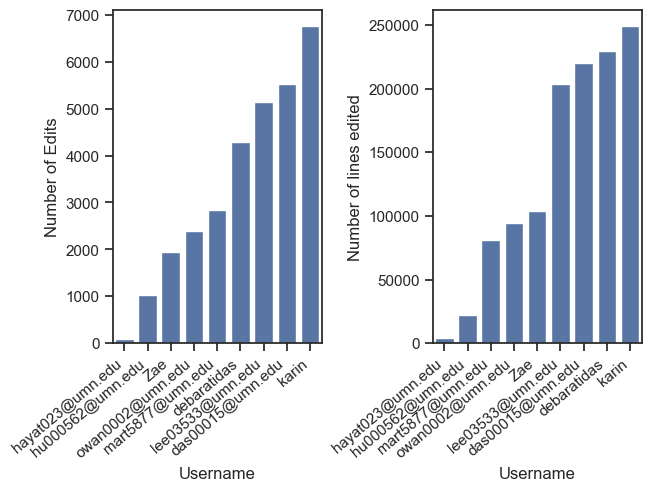

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import colorcet as cc

sns.set_theme(style="ticks")

print(df["username"].unique())

fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout = True) 

ax1 = sns.barplot(df1, ax=ax1)
ax1.set(xlabel='Username', ylabel='Number of Edits')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=40, ha="right")


ax2 = sns.barplot(df2, ax=ax2)
ax2.set(xlabel="Username", ylabel="Number of lines edited")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=40, ha="right")




/var/folders/b4/tsyrjt4j47766fqchqsyvycm0000gn/T/ipykernel_44049/1102478508.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right")


[Text(-5000.0, 0, '−5000'),
 Text(0.0, 0, '0'),
 Text(5000.0, 0, '5000'),
 Text(10000.0, 0, '10000'),
 Text(15000.0, 0, '15000'),
 Text(20000.0, 0, '20000'),
 Text(25000.0, 0, '25000'),
 Text(30000.0, 0, '30000'),
 Text(35000.0, 0, '35000')]

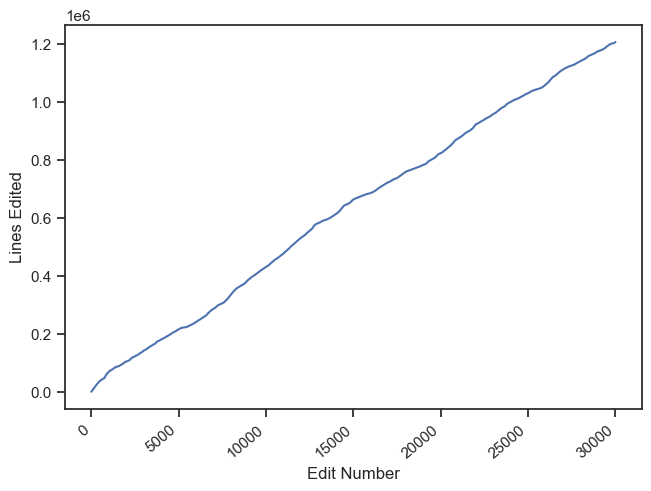

In [7]:
df["edits"] = df["editingLines"].apply(len)
df["cum_edits"] = df["edits"].cumsum()

fig, ax = plt.subplots(1, 1, constrained_layout = True) 

ax = sns.lineplot(df["cum_edits"], ax=ax)
ax.set(xlabel='Edit Number', ylabel='Lines Edited')
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right")


# File edits across time

Currenly only showing .tex or .bib files

Index([1701875222539, 1701907635170, 1701907646740, 1701907647197,
       1701907648145, 1701907648862, 1701907649662, 1701907650072,
       1701907653784, 1701907654542,
       ...
       1706033827596, 1706033850273, 1706033851131, 1706033858526,
       1706033875212, 1706033875676, 1706033948739, 1706033952453,
       1706033955271, 1706033961633],
      dtype='int64', name='timestamp', length=29531)


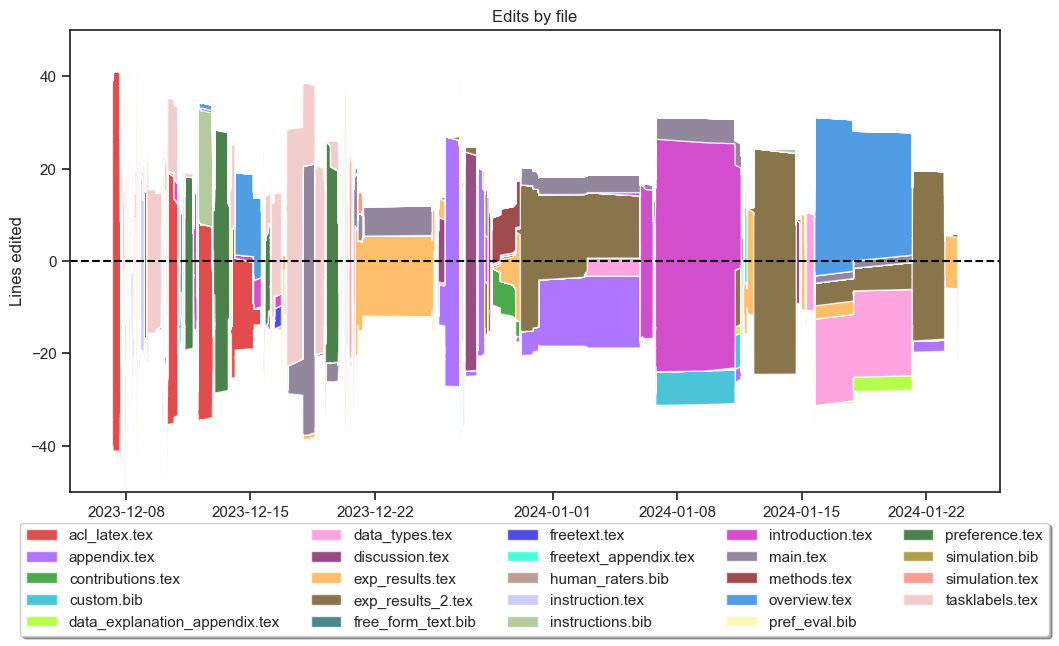

In [8]:


pivot_df = pd.pivot_table(df, values="edits", index="timestamp", columns="file", aggfunc="sum", fill_value=0)

relevant_files = [col for col in pivot_df.columns if '.tex' in col or '.bib' in col]

pivot_df = pivot_df[relevant_files]
window_size = 50  # Adjust the window size as needed
pivot_df = pivot_df.rolling(window=window_size).mean()

print(pivot_df.index)
pivot_df.index = pd.to_datetime(pivot_df.index, unit="ms")

fig, ax = plt.subplots(figsize=(12, 6)) 

#colors = sns.color_palette('hls', len(pivot_df.columns))
colors = sns.color_palette(cc.glasbey, n_colors=len(pivot_df.columns))

ax.set_prop_cycle('color', colors)

ax.stackplot(pivot_df.index, pivot_df.values.T, labels=pivot_df.columns, alpha=0.7, baseline="sym")

# Add labels and title
ax.set_xlabel('Timestamp')
ax.set_ylabel('Lines edited')
ax.set_title('Edits by file')
ax.set_ylim((-50,50))
ax.axhline(0, color="black", ls="--");
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))


ax.legend(pivot_df.columns,loc='upper center', bbox_to_anchor=(0.5, -0.05),
          fancybox=True, shadow=True, ncol=5)



In [9]:
import diff_match_patch as dmp_module

dmp = dmp_module.diff_match_patch()

state
Typing      26926
Paste        1514
Copy          962
UndoRedo      306
Cut           266
Scroll         22
Switch          9
Undoredo        1
Name: count, dtype: int64


<Axes: xlabel='state', ylabel='count'>

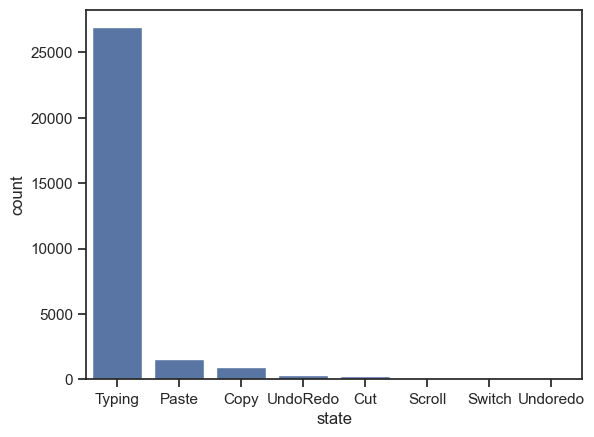

In [10]:
data = df["state"].value_counts()
print(data)
sns.barplot(data)

In [11]:
df.head()

idx = 21896

print(df.iloc[idx]["state"])
print(df.iloc[idx]["file"])
print(df.iloc[idx]["text"])
print(df.iloc[idx]["revision"])
print("\nLen:", len(df.iloc[idx]["revision"]))

Typing
main.tex
\caption{We summarize the research gap unearthed with each type of LLM-generated data. Our paper focuses on these unearthed research gaps for further analysis and stress testing LLM-generated data.}
\label{tab:transposed_related_summary}
\end{table*}
%%%%%%%%%%%%%%%%%%%%%%%%%%%
%\input{latex/exp_results} %<-- Karin exp rewrite draft
%%%%%%%%%%%%%%%%%%%%%%%%%%%%

%-------------------------------------------------------------------------
\section {Overall Takeaways}
\label{sec:sec3}
\input{latex/overview}
%\section{Experiments and Results}
%\input{latex/exp_results}
\section{Free-Form Text}
\label{sec:free_text}
\input{latex/freetext}

\section{Task Labels}
\input{latex/tasklabels}

\section{Instruction}
\label{sec:instruction}
\input{latex/instruction}


\section{Preference}
\input{latex/preference}

\section{Simulation}
\label{sec:simulation}
\input{latex/simulation}
%-----------------------------------------------------------------------

\begin{figure*}[ht!]
  \center

In [12]:
import re

def get_section_edited(text, line, editingLines):
    edit_line = int(line) - int(editingLines[0])

    matches = list(re.finditer("\\\\section", text))

    if not matches:
        return None

    end = matches[-1].start()
    # -1 so a failed 'rfind' maps to the first line.
    newline_table = {-1: 0}
    for i, m in enumerate(re.finditer('\\n', text), 1):
        # Don't find newlines past our last match.
        offset = m.start()
        if offset > end:
            break
        newline_table[offset] = i

    matches_idx = []
    
    for m in matches:
        newline_offset = text.rfind('\n', 0, m.start())
        newline_end = text.find('\n', m.end())  # '-1' gracefully uses the end.
        line = text[newline_offset + 1:newline_end]
        line_number = newline_table[newline_offset]
        #print (line_number, line)

        matches_idx.append((line_number, line))

    if (len(matches_idx) == 0):
        #print("no matches", matches_idx)
        return None
    elif (edit_line < matches_idx[0][0]):
        return "no section"
        #raise Exception("too early")
    else:
        #print("edit_line", edit_line, "output:", next(((line_number, line) for (line_number, line) in matches_idx if line_number < edit_line), 0))
        string = next((line for (line_number, line) in matches_idx if line_number < edit_line), 0)
        if (isinstance(string, str)):
            return string[string.find("{")+1:string.find("}")]
        else:
            return None
        

    

In [14]:

df1 = df.loc[df["file"] == "main.tex"]


idx = 2

state = df1.iloc[idx]["state"]
fname = df1.iloc[idx]["file"]
text = df1.iloc[idx]["text"]
changes = df1.iloc[idx]["changes"]
revision = df1.iloc[idx]["revision"]
editingLines = df1.iloc[idx]["editingLines"]
line = df1.iloc[idx]["line"]



print("length", len(text))
print("total lines", text.count("\n") + 1)
print("also total lines", len(editingLines))
print("absolute line", line)

print("\n\n\n")
get_section_edited(text, line, editingLines)

length 3555
total lines 35
also total lines 35
absolute line 336






'Conclusion'

/var/folders/b4/tsyrjt4j47766fqchqsyvycm0000gn/T/ipykernel_44049/3892507742.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["section"] = df1.apply(lambda x: get_section_edited(x["text"], x["line"], x["editingLines"]), axis=1)
/var/folders/b4/tsyrjt4j47766fqchqsyvycm0000gn/T/ipykernel_44049/3892507742.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right")


[Text(0, 0, 'Conclusion'),
 Text(1, 0, 'Overall Takeaways'),
 Text(2, 0, 'no section'),
 Text(3, 0, 'Overall Discussion'),
 Text(4, 0, 'Instruction'),
 Text(5, 0, 'Key Takeaways'),
 Text(6, 0, 'Introduction'),
 Text(7, 0, 'Types of Stress Testing Methods'),
 Text(8, 0, 'Task Labels'),
 Text(9, 0, 'Free-Form Text'),
 Text(10, 0, 'Preference'),
 Text(11, 0, 'Simulation'),
 Text(12, 0, 'Acknowledgements'),
 Text(13, 0, 'Experiments and Results')]

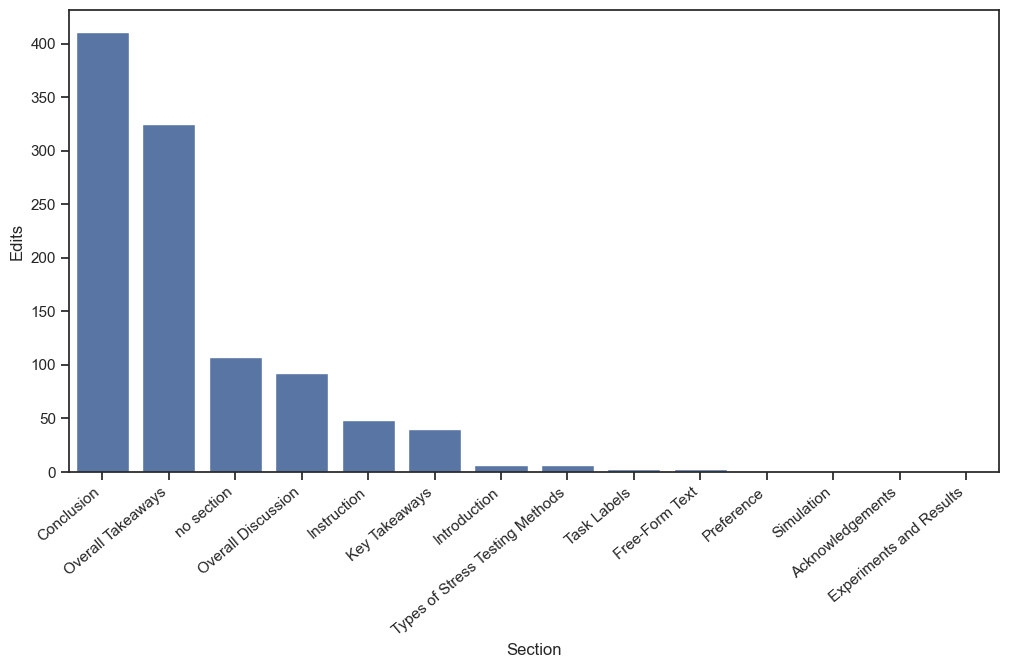

In [15]:
df1["section"] = df1.apply(lambda x: get_section_edited(x["text"], x["line"], x["editingLines"]), axis=1)

fig, ax = plt.subplots(figsize=(12, 6)) 

sns.barplot(df1["section"].value_counts(), ax=ax)
ax.set(xlabel='Section', ylabel='Edits')
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right")

section        Acknowledgements  Conclusion  Experiments and Results  \
timestamp                                                              
1702662771997                 0           1                        0   
1702662772124                 0           1                        0   
1702662772256                 0           1                        0   
1702662772393                 0           1                        0   
1702663180547                 0           1                        0   

section        Free-Form Text  Instruction  Introduction  Key Takeaways  \
timestamp                                                                 
1702662771997               0            0             0              0   
1702662772124               0            0             0              0   
1702662772256               0            0             0              0   
1702662772393               0            0             0              0   
1702663180547               0            0   

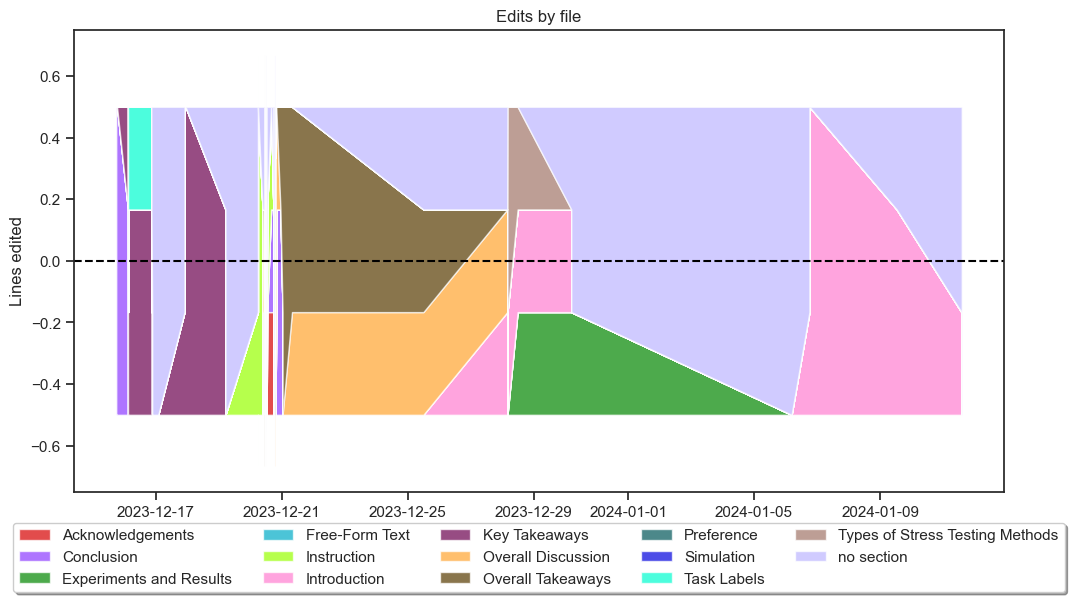

In [16]:
pivot_df = pd.pivot_table(df1, index="timestamp", columns="section", aggfunc="size", fill_value=0)
print(pivot_df.head())

window_size = 3  # Adjust the window size as needed
pivot_df = pivot_df.rolling(window=window_size).mean()

print(pivot_df.index)
pivot_df.index = pd.to_datetime(pivot_df.index, unit="ms")

fig, ax = plt.subplots(figsize=(12, 6)) 

#colors = sns.color_palette('hls', len(pivot_df.columns))
colors = sns.color_palette(cc.glasbey, n_colors=len(pivot_df.columns))

ax.set_prop_cycle('color', colors)

ax.stackplot(pivot_df.index, pivot_df.values.T, labels=pivot_df.columns, alpha=0.7, baseline="sym")

# Add labels and title
ax.set_xlabel('Timestamp')
ax.set_ylabel('Lines edited')
ax.set_title('Edits by file')
ax.set_ylim((-0.75,0.75))
ax.axhline(0, color="black", ls="--");
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))


ax.legend(pivot_df.columns,loc='upper center', bbox_to_anchor=(0.5, -0.05),
          fancybox=True, shadow=True, ncol=5)